# Abalon Regression

- 6주차 과제
- 딥러닝 - 회귀

In [ ]:
import pandas as pd
import numpy as np

path = '../../data/abalone.csv'

df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # 불필요한 Unnamed 컬럼 제거

X = df.drop('Rings', axis=1)
y = df['Rings']

# Sex는 M or F(=> 텍스트임)이므로 해당 열에 대해 원 핫 인코딩
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

print(y.describe())

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64


Epoch 1/50


c:\Users\kiw60\Desktop\intro-to-ai\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 42.5044 - mae: 5.2853 - val_loss: 13.1842 - val_mae: 2.6705
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.1780 - mae: 2.2787 - val_loss: 6.3641 - val_mae: 1.7436
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1171 - mae: 1.9974 - val_loss: 5.5649 - val_mae: 1.6569
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.4987 - mae: 1.9132 - val_loss: 5.4294 - val_mae: 1.6495
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9464 - mae: 1.8582 - val_loss: 5.2675 - val_mae: 1.6285
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5165 - mae: 1.7999 - val_loss: 5.2667 - val_mae: 1.6212
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3485 - mae: 1.8143 - val_loss: 5.1744 - val_mae: 1.6302
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2256 - mae: 1.7854 - val_loss: 5.3608 - val_mae: 1.5810
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.90

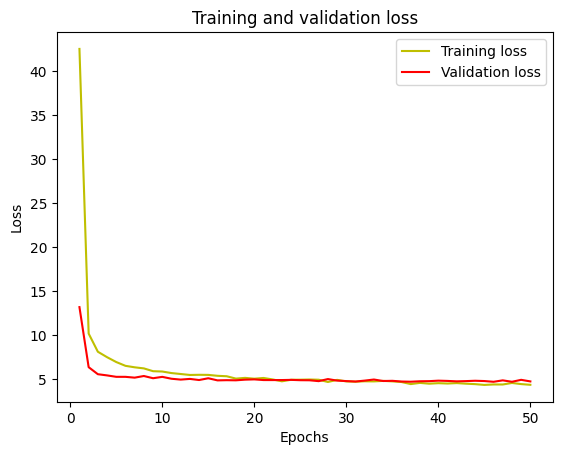

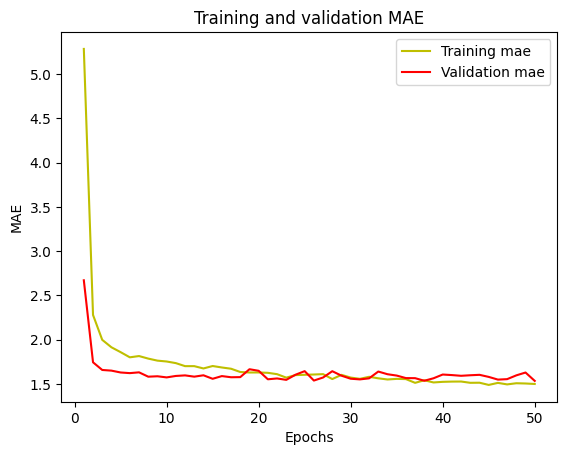

MSE  : 4.6285
MAE  : 1.4842
R²   : 0.5738


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

scaler = StandardScaler()
X = scaler.fit_transform(X)

# 회귀(Regression)에서는 타겟이 연속값이므로 원-핫 인코딩을 하지 않습니다.
# Y = pd.get_dummies(y).values 삭제됨

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test).flatten()

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

plt.plot(epochs_range, loss, 'y', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

mae = history.history['mae']
val_mae = history.history['val_mae']
plt.plot(epochs_range, mae, 'y', label='Training mae')
plt.plot(epochs_range, val_mae, 'r', label='Validation mae')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

print(f'MSE  : {mean_squared_error(y_test, y_pred):.4f}')
print(f'MAE  : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'R²   : {r2_score(y_test, y_pred):.4f}')